In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 12.5.0


In [2]:
import pymeshlab
print("pymeshlab imported successfully!")


pymeshlab imported successfully!


In [3]:
import pymeshlab
import numpy as np

target = {
    "model": "/home/hawk/GitDir/Blender's files/Edited files/quadcopter.stl",
    "unit": "m",
    "location": (0, 0, 0),
}

_Plot the model_


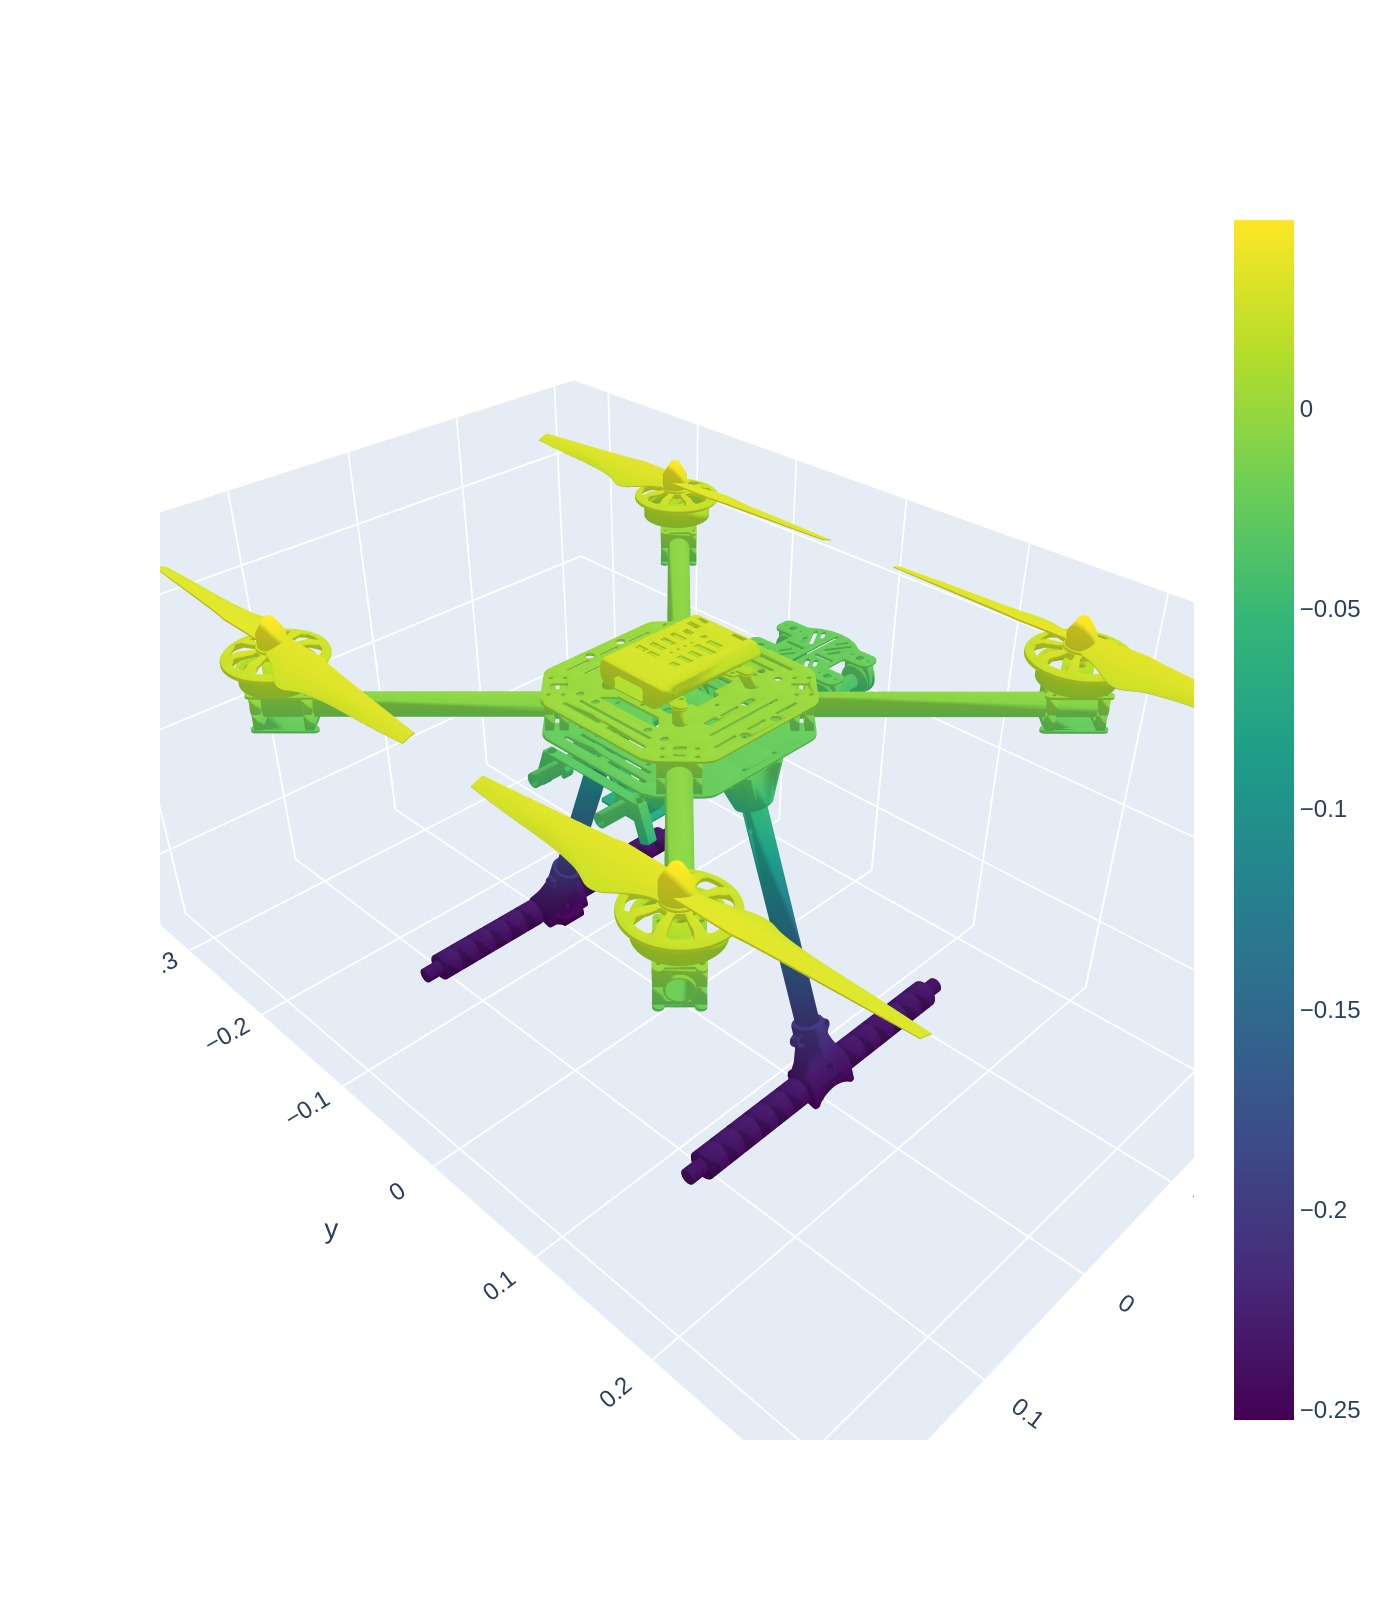

In [4]:
import plotly.graph_objs as go
from IPython.display import Image

ms = pymeshlab.MeshSet()
ms.load_new_mesh(target["model"])
t_mesh = ms.current_mesh()
v_matrix = np.array(t_mesh.vertex_matrix())
f_matrix = np.array(t_mesh.face_matrix())

fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=v_matrix[:, 0],
        y=v_matrix[:, 1],
        z=v_matrix[:, 2],
        i=f_matrix[:, 0],
        j=f_matrix[:, 1],
        k=f_matrix[:, 2],
        intensity=v_matrix[:, 2],
        colorscale="Viridis",
    )
)
fig["layout"]["scene"]["aspectmode"] = "data"
fig["layout"]["height"] = 800

# uncomment this to display interactive plot
# fig.show()

# display static image to reduce size on radarsimx.com
img_bytes = fig.to_image(format="jpg", scale=2)
display(Image(img_bytes))

## Simulate RCS vs Observation Angle


In [5]:
# import time

# from radarsimpy.rt import rcs_sbr

# phi = np.arange(-180, 180, 1)
# theta = 90
# freq = 76e9
# pol = [0, 0, 1]
# density = 0.1

# rcs = np.zeros_like(phi)

# tic = time.time()
# for phi_idx, phi_ang in enumerate(phi):
#     rcs[phi_idx] = 10 * np.log10(
#         rcs_sbr([target], freq, phi_ang, theta, pol, density=density)
#     )
# toc = time.time()

# print("Exec time :" + str(toc - tic) + "s")

_Plot RCS vs angle_


In [6]:
# fig = go.Figure()

# fig.add_trace(go.Scatter(x=phi, y=rcs))

# fig.update_layout(
#     title="RCS vs Observation Angle",
#     yaxis=dict(title="RCS (dBsm)"),
#     xaxis=dict(title="Observation angle (Degree)", dtick=20),
# )

# # uncomment this to display interactive plot
# # fig.show()

# # display static image to reduce size on radarsimx.com
# img_bytes = fig.to_image(format="jpg", scale=2)
# display(Image(img_bytes))

Exec time : 125.67321157455444s


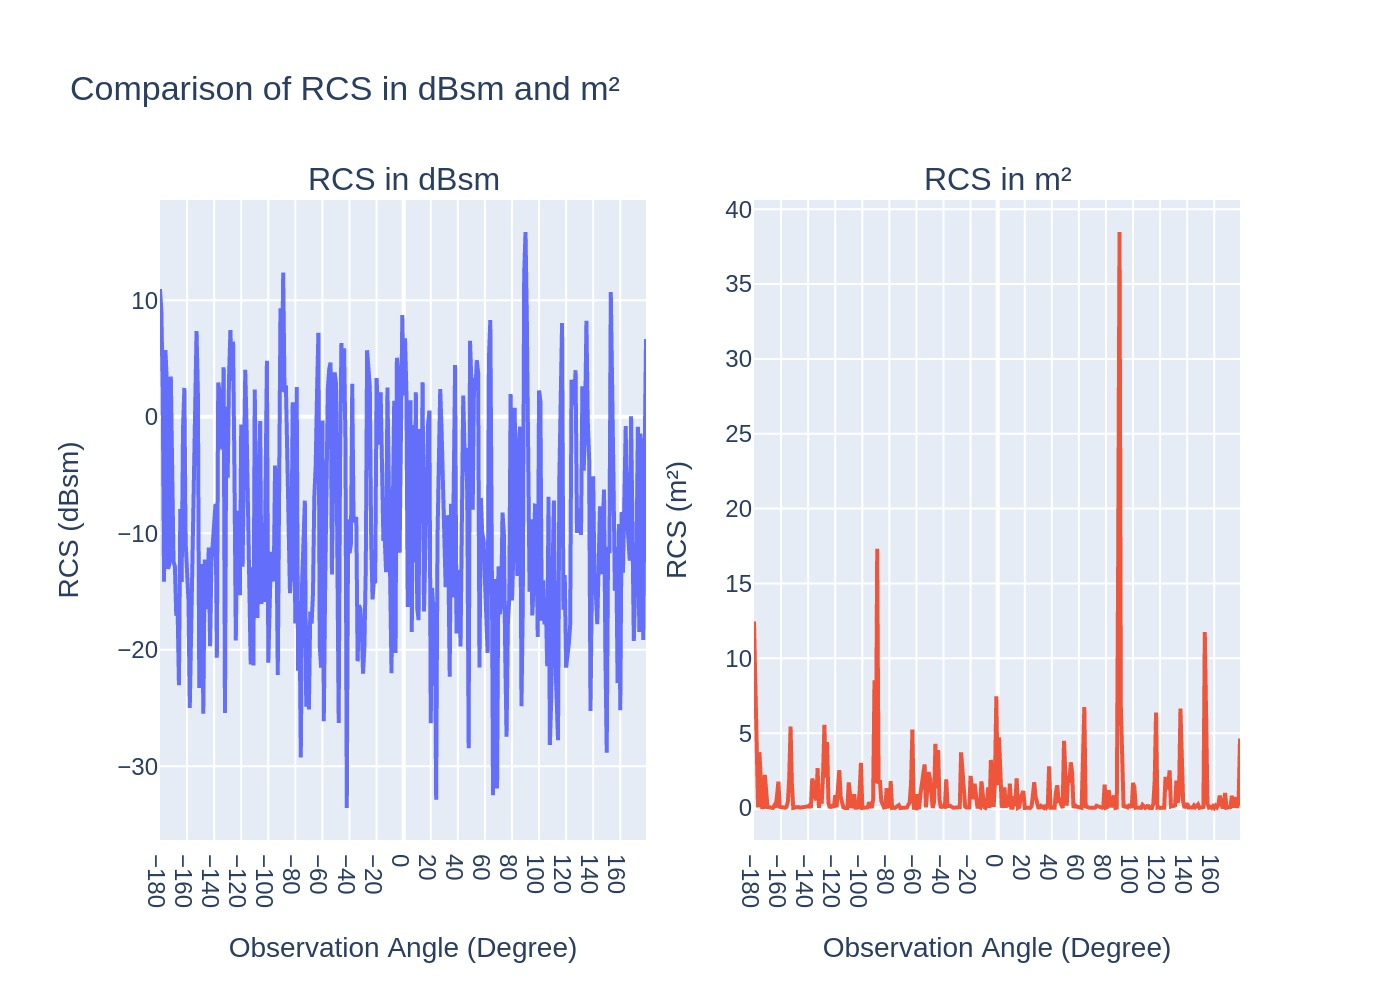

In [7]:
import time
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import Image
from radarsimpy.rt import rcs_sbr

# Define parameters
phi = np.arange(-180, 180, 1)
theta = 90
freq = 76e9
pol = [0, 0, 1]
density = 0.1

# Initialize RCS arrays
rcs_db = np.zeros_like(phi, dtype=float)
rcs_m2 = np.zeros_like(phi, dtype=float)

# Compute RCS values
tic = time.time()
for phi_idx, phi_ang in enumerate(phi):
    rcs_value = rcs_sbr([target], freq, phi_ang, theta, pol, density=density)
    rcs_db[phi_idx] = 10 * np.log10(rcs_value)  # Convert to dBsm
    rcs_m2[phi_idx] = rcs_value  # Keep as m²
toc = time.time()

print("Exec time : " + str(toc - tic) + "s")

# Create subplots (1 row, 2 columns)
fig = make_subplots(rows=1, cols=2, subplot_titles=("RCS in dBsm", "RCS in m²"))

# Add RCS in dBsm plot
fig.add_trace(go.Scatter(x=phi, y=rcs_db, name="RCS (dBsm)"), row=1, col=1)

# Add RCS in m² plot
fig.add_trace(go.Scatter(x=phi, y=rcs_m2, name="RCS (m²)"), row=1, col=2)

# Update layout
fig.update_layout(
    title_text="Comparison of RCS in dBsm and m²",
    showlegend=False,
)

# Update axes labels
fig.update_xaxes(title_text="Observation Angle (Degree)", dtick=20, row=1, col=1)
fig.update_xaxes(title_text="Observation Angle (Degree)", dtick=20, row=1, col=2)

fig.update_yaxes(title_text="RCS (dBsm)", row=1, col=1)
fig.update_yaxes(title_text="RCS (m²)", row=1, col=2)

# Uncomment to display interactive plot
# fig.show()

# Display static image
img_bytes = fig.to_image(format="jpg", scale=2)
display(Image(img_bytes))
